# Imports

In [13]:
import os
os.environ['NUMPY_EXPERIMENTAL_ARRAY_FUNCTION'] = '0'
import warnings
warnings.filterwarnings("ignore")
import sys, pathlib
path = (pathlib.Path.home() / 'PILOT').as_posix()
if path not in sys.path:
    sys.path.append(path)
    
import pandas as pd
import numpy as np
import time
import cProfile
import pstats

from sklearn.datasets import make_regression
from sklearn.metrics import r2_score

from pilot import Pilot, Tree
from pilot import pypilot

%load_ext line_profiler
%load_ext autoreload
%autoreload 2

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Analyze

## Run experiments

In [9]:
results = []
for n_obs in [100, 1000, 10000]:
    for n_feat in [2, 10, 50]:
        print(n_obs, n_feat)
        for i in range(5):
            X, y = make_regression(n_samples=n_obs, n_features=n_feat, noise=1, random_state=i)
            for node in ['lin', 'pcon', 'plin', 'blin']:
                pilot = Pilot.PILOT(
                    max_depth=12,
                    min_sample_split=10,
                    min_sample_leaf=5,
                    step_size=1,
                    random_state=42,
                    truncation_factor=3,
                    rel_tolerance=0,
                    df_settings=None,
                    regression_nodes=['con'] + [node],
                    min_unique_values_regression = 5
                )
                t1 = time.time()
                pilot.fit(X, y)
                t2 = time.time()
                results.append({
                    'n_obs': n_obs,
                    'n_feat': n_feat,
                    'node': node,
                    'time': t2 - t1,
                    'n_nodes': pilot.recursion_counter[node]
                })
pd.DataFrame(results).to_csv(pathlib.Path.home() / 'PILOT' / 'Output' / 'compute_time_by_node.csv', index=False)

100 2
100 10
100 50
1000 2
1000 10
1000 50
10000 2
10000 10
10000 50


In [11]:
df = pd.read_csv(pathlib.Path.home() / 'PILOT' / 'Output' / 'compute_time_by_node.csv')

In [12]:
df.groupby(['n_obs', 'n_feat', 'node'])['time'].mean().unstack()

node               blin         lin       pcon       plin
n_obs n_feat                                             
100   2        0.006189    0.003123   0.005649   0.004661
      10       0.028739    0.068292   0.014077   0.009399
      50       0.148465    0.468542   0.071069   0.098870
1000  2        0.068470    0.043506   0.091374   0.038721
      10       0.922333    1.034789   0.265020   0.448699
      50       6.926436    7.316072   1.744689   2.786573
10000 2        1.427707    1.507117   1.704483   1.232319
      10      17.349678   39.458181   9.239185  14.700917
      50      98.408179  222.895010  42.090174  83.962624

In [13]:
df.groupby(['n_obs', 'n_feat', 'node'])['n_nodes'].mean().unstack()

node           blin   lin   pcon   plin
n_obs n_feat                           
100   2         3.4   2.8   10.2    3.8
      10        7.6  27.6    4.6    3.0
      50       10.4  30.4    3.4    5.8
1000  2         6.2   3.0  102.4    7.8
      10       59.2  20.4   41.0   55.6
      50       55.6  21.6   46.6   58.2
10000 2         4.0   2.8  875.2    6.0
      10      158.2  18.6  379.6  201.6
      50      153.8  19.2  450.4  163.0

## Check trees built by lin vs blin

In [49]:
X, y = make_regression(n_samples=1000, n_features=10, noise=1, random_state=i)
pilot = Pilot.PILOT(
    max_depth=12,
    min_sample_split=10,
    min_sample_leaf=5,
    step_size=1,
    random_state=42,
    truncation_factor=3,
    rel_tolerance=0,
    df_settings=None,
    regression_nodes=['con'] + ['lin'],
    min_unique_values_regression = 5
)
pilot.fit(X, y)
print(pilot.tree_depth)
pilot.print_tree()

0
                                                                                                                                                                                        -->END 1105.394
                                                                                                                                                                                --> con (9, -1.0) 1105.394 (0.0, 0.0) (0.0, 0.0)
                                                                                                                                                                        --> lin 8 1137.046 (0.181, -0.004) None
                                                                                                                                                                --> lin 3 1190.817 (0.241, -0.005) None
                                                                                                                                                        --> lin 1 132

In [48]:
X, y = make_regression(n_samples=1000, n_features=10, noise=1, random_state=i)
pilot = Pilot.PILOT(
    max_depth=12,
    min_sample_split=10,
    min_sample_leaf=5,
    step_size=1,
    random_state=42,
    truncation_factor=3,
    rel_tolerance=0,
    df_settings=None,
    regression_nodes=['con'] + ['blin'],
    min_unique_values_regression = 5
)
pilot.fit(X, y)
print(pilot.tree_depth)
pilot.print_tree()

12
                                        -->END 120496.309
                                --> blin (3, -2.016) 4075203.704 (155.221, 214.862) (48.506, -0.317)
                                                                                -->END 4104.539
                                                                        --> con (2, -1.0) 4104.539 (0.0, 1.103) (0.0, 0.0)
                                                                --> blin (0, 0.463) 11837.301 (30.512, 5.907) (-6.721, 23.128)
                                                                        -->END 901.462
                                                        --> blin (9, -0.613) 255784.574 (32.21, -18.626) (51.773, -6.635)
                                                                                -->END 2201.175
                                                                        --> blin (1, -1.203) 41739.737 (12.499, -15.067) (25.305, 0.34)
                                                   

2
{'lin': 0, 'blin': 2, 'pcon': 0, 'plin': 0, 'pconc': 0}
                                -->END 4075203.704
                        --> blin (8, -0.395) 15698127.963 (41.892, -16.583) (66.006, -7.064)
                                -->END 8394211.489
                --> blin (4, 2.414) 25206096.554 (93.523, 4.262) (-7.306, 247.698)
                        -->END 108464.05


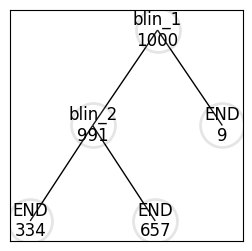

In [66]:
X, y = make_regression(n_samples=1000, n_features=10, noise=1, random_state=i)
pilot = Pilot.PILOT(
    max_depth=12,
    min_sample_split=10,
    min_sample_leaf=5,
    step_size=1,
    random_state=42,
    truncation_factor=3,
    rel_tolerance=0,
    df_settings=None,
    regression_nodes=['con'] + ['blin'],
    min_unique_values_regression = 5,
    max_nodes=2
)
pilot.fit(X, y)
print(pilot.tree_depth)
print(pilot.recursion_counter)
pilot.print_tree()
Tree.visualize_tree(pilot.model_tree, X, figsize=(3, 3))

## Experiment with fixed number of nodes

In [61]:
results = []
for n_obs in [100, 1000, 10000]:
    for n_feat in [2, 10, 50]:
        print(n_obs, n_feat)
        for i in range(5):
            print('\t', i)
            X, y = make_regression(n_samples=n_obs, n_features=n_feat, noise=1, random_state=i)
            for node in ['lin', 'pcon', 'plin', 'blin']:
                pilot = Pilot.PILOT(
                    max_depth=12,
                    min_sample_split=10,
                    min_sample_leaf=5,
                    step_size=1,
                    random_state=42,
                    truncation_factor=3,
                    rel_tolerance=0,
                    df_settings=None,
                    regression_nodes=['con'] + [node],
                    min_unique_values_regression = 5,
                    max_nodes=2,
                )
                t1 = time.time()
                pilot.fit(X, y)
                t2 = time.time()
                results.append({
                    'n_obs': n_obs,
                    'n_feat': n_feat,
                    'node': node,
                    'time': t2 - t1,
                    'n_nodes': pilot.recursion_counter[node]
                })
pd.DataFrame(results).to_csv(pathlib.Path.home() / 'PILOT' / 'Output' / 'compute_time_by_node_max2.csv', index=False)

100 2
100 10
100 50
1000 2
1000 10
1000 50
10000 2
10000 10
10000 50


In [62]:
df = pd.read_csv(pathlib.Path.home() / 'PILOT' / 'Output' / 'compute_time_by_node_max2.csv')

In [67]:
df.groupby(['n_obs', 'n_feat', 'node'])['time'].mean().unstack().round(3)

node            blin     lin    pcon    plin
n_obs n_feat                                
100   2        0.005   0.003   0.005   0.004
      10       0.023   0.009   0.008   0.008
      50       0.081   0.044   0.069   0.058
1000  2        0.060   0.027   0.031   0.026
      10       0.287   0.164   0.118   0.182
      50       1.936   1.400   1.400   1.398
10000 2        1.160   1.267   0.738   0.923
      10       5.635   6.775   4.075   5.647
      50      37.088  41.727  23.602  36.022

# Profile by node type

In [140]:
results = []
for n_obs in [1000, 10000]:
    for n_feat in [2, 10]:
        print(n_obs, n_feat)
        X, y = make_regression(n_samples=n_obs, n_features=n_feat, noise=1, random_state=i)
        for node in ['lin', 'pcon', 'plin', 'blin']:
            filename = pathlib.Path.home() / 'PILOT' / 'Output' / 'profile_results' / f'profile_results_{node}_{n_obs}_{n_feat}_max2_code_update_X_add.prof'
            if node == 'all':
                node = ['lin', 'pcon', 'plin', 'blin']
            p = pypilot.PILOT(
                max_depth=12,
                min_sample_split=10,
                min_sample_leaf=5,
                step_size=1,
                random_state=42,
                truncation_factor=3,
                rel_tolerance=0,
                df_settings=None,
                regression_nodes=['con'] + [node],
                min_unique_values_regression = 5,
                max_nodes=2,
            )
            cProfile.run('p.fit(X, y)', filename.as_posix())
            
            

1000 2
1000 10
10000 2
10000 10


In [141]:
postfix = "_max2_code_update_X_add"
results = []
for node in ['lin', 'pcon', 'plin', 'blin', 'all']:
    filename = (pathlib.Path.home() / 'PILOT' / 'Output' / 'profile_results' / f'profile_results_{node}_10000_10{postfix}.prof').as_posix()
    stats = pstats.Stats(filename)
    data = []
    for func, stat in stats.strip_dirs().stats.items():
        file_name, line, func_name = func
        cc, nc, tt, ct, callers = stat
        data.append([file_name, line, func_name, cc, nc, tt, ct])

    # Creating a DataFrame
    df = pd.DataFrame(data, columns=['File', 'Line', 'Function', 'Primitive Calls', 'Total Calls', 'Total Time', 'Cumulative Time'])

    # Optional: sort the DataFrame by cumulative time
    df = df.sort_values(by='Cumulative Time', ascending=False).assign(node=node)
    results.append(df)
pd.concat(results).to_csv(pathlib.Path.home() / 'PILOT' / 'Output' / 'profile_results' / f'profile_results{postfix}.csv', index=False)

In [144]:
df = pd.read_csv(pathlib.Path.home() / 'PILOT' / 'Output' / 'profile_results' / 'profile_results_max2_code_update_X_add.csv')

In [145]:
df.loc[df['File'] == 'pypilot.py'].pivot(index='Function', columns='node', values='Total Time').round(4)

node,all,blin,lin,pcon,plin
Function,,,,,
<listcomp>,0.0000,0.0000,0.0001,0.0000,0.0000
best_split,0.0007,9.2399,0.0026,8.3750,14.9459
build_tree,0.0002,0.0011,0.0008,0.0015,0.0016
calculate_rss,NaN,2.6134,NaN,2.8759,3.1918
fit,0.0003,0.0002,0.0003,0.0003,0.0002
get_sorted_X_y,0.0035,0.0096,0.0108,0.0136,0.0105
isin,0.0000,0.0002,0.0001,0.0002,0.0001
loss_fun,0.0001,1.3150,0.0008,1.4083,1.5186
preprocess_blin,NaN,0.0007,NaN,NaN,NaN


In [146]:
def color_first_level_columns(df):
    # Create an empty DataFrame of the same shape as df to hold the styles
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    cmap = {'Total Calls': 'lightgreen', 'Total Time': 'lightred', 'Cumulative Time': 'lightblue'}
    tmap = {'Total Calls': 'black', 'Total Time': 'white', 'Cumulative Time': 'black'}
    
    # Loop through the columns and apply the corresponding color
    for col in df.columns:
        first_level = col[0]  # Extract the first level
        styles[col] = f"background-color: {cmap.get(first_level, '')}; color: {tmap.get(first_level, '')}"  # Apply the color
    
    return styles

table = df.assign(Function=df['Function'].str.replace(r'<|>', '')).pivot(index=['File', 'Function', 'Line'], columns='node', values=['Total Calls', 'Total Time', 'Cumulative Time']).loc[lambda d: d.index.get_level_values('Line') != -1].round(4)

table.assign(key=table.loc[:, ('Cumulative Time', slice(None))].max(axis=1)).sort_values('key', ascending=False).drop(columns=['key']).head(20).style.format('{:,.2f}').apply(color_first_level_columns, axis=None)

In [132]:
table = df.assign(Function=df['Function'].str.replace(r'<|>', '')).pivot(index=['File', 'Function', 'Line'], columns='node', values=['Total Calls', 'Total Time', 'Cumulative Time']).loc[lambda d: d.index.get_level_values('File') != '~'].round(4)

table.assign(key=table.loc[:, ('Cumulative Time', slice(None))].max(axis=1)).sort_values('key', ascending=False).drop(columns=['key']).head(20).style.format('{:,.2f}').apply(color_first_level_columns, axis=None)

# Profile by node type after refactoring

In [40]:
results = []
for n_obs in [1000, 10000]:
    for n_feat in [2, 10]:
        print(n_obs, n_feat)
        X, y = make_regression(n_samples=n_obs, n_features=n_feat, noise=1, random_state=1)
        for node in ['lin', 'pcon', 'plin', 'blin']:
            filename = pathlib.Path.home() / 'PILOT' / 'Output' / 'profile_results' / f'profile_results_refactor_{node}_{n_obs}_{n_feat}.prof'
            if node == 'all':
                node = ['lin', 'pcon', 'plin', 'blin']
            p = pypilot.PILOT(
                max_depth=12,
                min_sample_split=10,
                min_sample_leaf=5,
                step_size=1,
                random_state=42,
                truncation_factor=3,
                rel_tolerance=0,
                df_settings=None,
                regression_nodes=['con'] + [node],
                min_unique_values_regression = 5,
                max_nodes=2,
            )
            cProfile.run('p.fit(X, y)', filename.as_posix())
            
            

1000 2
1000 10
10000 2
10000 10


In [42]:
results = []
for node in ['lin', 'pcon', 'plin', 'blin']:
    filename = (pathlib.Path.home() / 'PILOT' / 'Output' / 'profile_results' / f'profile_results_refactor_{node}_10000_10.prof').as_posix()
    stats = pstats.Stats(filename)
    data = []
    for func, stat in stats.strip_dirs().stats.items():
        file_name, line, func_name = func
        cc, nc, tt, ct, callers = stat
        data.append([file_name, line, func_name, cc, nc, tt, ct])

    # Creating a DataFrame
    df = pd.DataFrame(data, columns=['File', 'Line', 'Function', 'Primitive Calls', 'Total Calls', 'Total Time', 'Cumulative Time'])

    # Optional: sort the DataFrame by cumulative time
    df = df.sort_values(by='Cumulative Time', ascending=False).assign(node=node)
    results.append(df)
pd.concat(results).to_csv(pathlib.Path.home() / 'PILOT' / 'Output' / 'profile_results' / f'profile_results_refactor.csv', index=False)

In [43]:
df = pd.read_csv(pathlib.Path.home() / 'PILOT' / 'Output' / 'profile_results' / 'profile_results_refactor.csv')

In [44]:
df.loc[df['File'] == 'pypilot.py'].pivot(index='Function', columns='node', values='Total Time').round(4)

node,blin,lin,pcon,plin
Function,,,,
<listcomp>,0.0000,0.0001,0.0001,0.0000
best_split,10.1339,0.0023,6.6273,14.5918
build_tree,0.0016,0.0008,0.0014,0.0015
calculate_rss,5.1646,NaN,4.0500,5.1898
fit,0.0002,0.0003,0.0003,0.0002
get_sorted_X_y,0.0095,0.0085,0.0099,0.0089
isin,0.0001,0.0001,0.0002,0.0001
loss_fun,1.3715,0.0008,1.0435,1.3629
num,NaN,NaN,NaN,0.7257


In [45]:
def color_first_level_columns(df):
    # Create an empty DataFrame of the same shape as df to hold the styles
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    cmap = {'Total Calls': 'lightgreen', 'Total Time': 'lightred', 'Cumulative Time': 'lightblue'}
    tmap = {'Total Calls': 'black', 'Total Time': 'white', 'Cumulative Time': 'black'}
    
    # Loop through the columns and apply the corresponding color
    for col in df.columns:
        first_level = col[0]  # Extract the first level
        styles[col] = f"background-color: {cmap.get(first_level, '')}; color: {tmap.get(first_level, '')}"  # Apply the color
    
    return styles

table = df.assign(Function=df['Function'].str.replace(r'<|>', '')).pivot(index=['File', 'Function', 'Line'], columns='node', values=['Total Calls', 'Total Time', 'Cumulative Time']).loc[lambda d: d.index.get_level_values('Line') != -1].round(4)

table.assign(key=table.loc[:, ('Cumulative Time', slice(None))].max(axis=1)).sort_values('key', ascending=False).drop(columns=['key']).head(20).style.format('{:,.2f}').apply(color_first_level_columns, axis=None)

In [46]:
table = df.assign(Function=df['Function'].str.replace(r'<|>', '')).pivot(index=['File', 'Function', 'Line'], columns='node', values=['Total Calls', 'Total Time', 'Cumulative Time']).loc[lambda d: d.index.get_level_values('File') != '~'].round(4)

table.assign(key=table.loc[:, ('Cumulative Time', slice(None))].max(axis=1)).sort_values('key', ascending=False).drop(columns=['key']).head(20).style.format('{:,.2f}').apply(color_first_level_columns, axis=None)

In [47]:
timings = []
for i in range(10):
    print(i)
    X, y = make_regression(n_samples=10000, n_features=5, noise=1, random_state=i)
    t1 = time.time()
    print('pypilot')
    p = pypilot.PILOT(
        max_depth=12,
        min_sample_split=10,
        min_sample_leaf=5,
        step_size=1,
        random_state=42,
        truncation_factor=3,
        rel_tolerance=0,
        df_settings=None,
        regression_nodes=['con'] + ['blin'],
        min_unique_values_regression = 5,
        max_nodes=2,
    )
    p.fit(X, y)
    t2 = time.time()
    print('numba')
    p = Pilot.PILOT(
        max_depth=12,
        min_sample_split=10,
        min_sample_leaf=5,
        step_size=1,
        random_state=42,
        truncation_factor=3,
        rel_tolerance=0,
        df_settings=None,
        regression_nodes=['con'] + ['blin'],
        min_unique_values_regression = 5,
        max_nodes=2,
    )
    p.fit(X, y)
    t3 = time.time()
    timings.append({'pypilot': t2 - t1, 'numba': t3 - t2})

KeyboardInterrupt: 

In [36]:
timings

0.9961665158888156